In [2]:
import cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
from glob import glob
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

In [24]:
glob_path = [i for i in glob('Dataset\*\*\*.mp4')]
output_label = [i for i in glob('Dataset\*\*')]

glob_path,output_label

(['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_953

In [25]:
random_video = random.choice(glob_path)
print(random_video.split("\\")[-2:])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

['3. happy', 'MVI_5183.mp4']
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


In [26]:
cap = cv2.VideoCapture(random_video)
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (1080, 1920, 3)


In [27]:
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

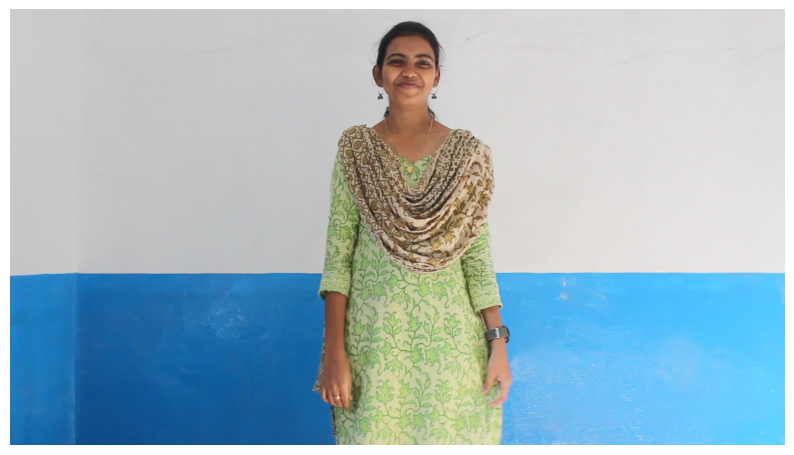

In [28]:
display_cv2_img(img)
cap.release()

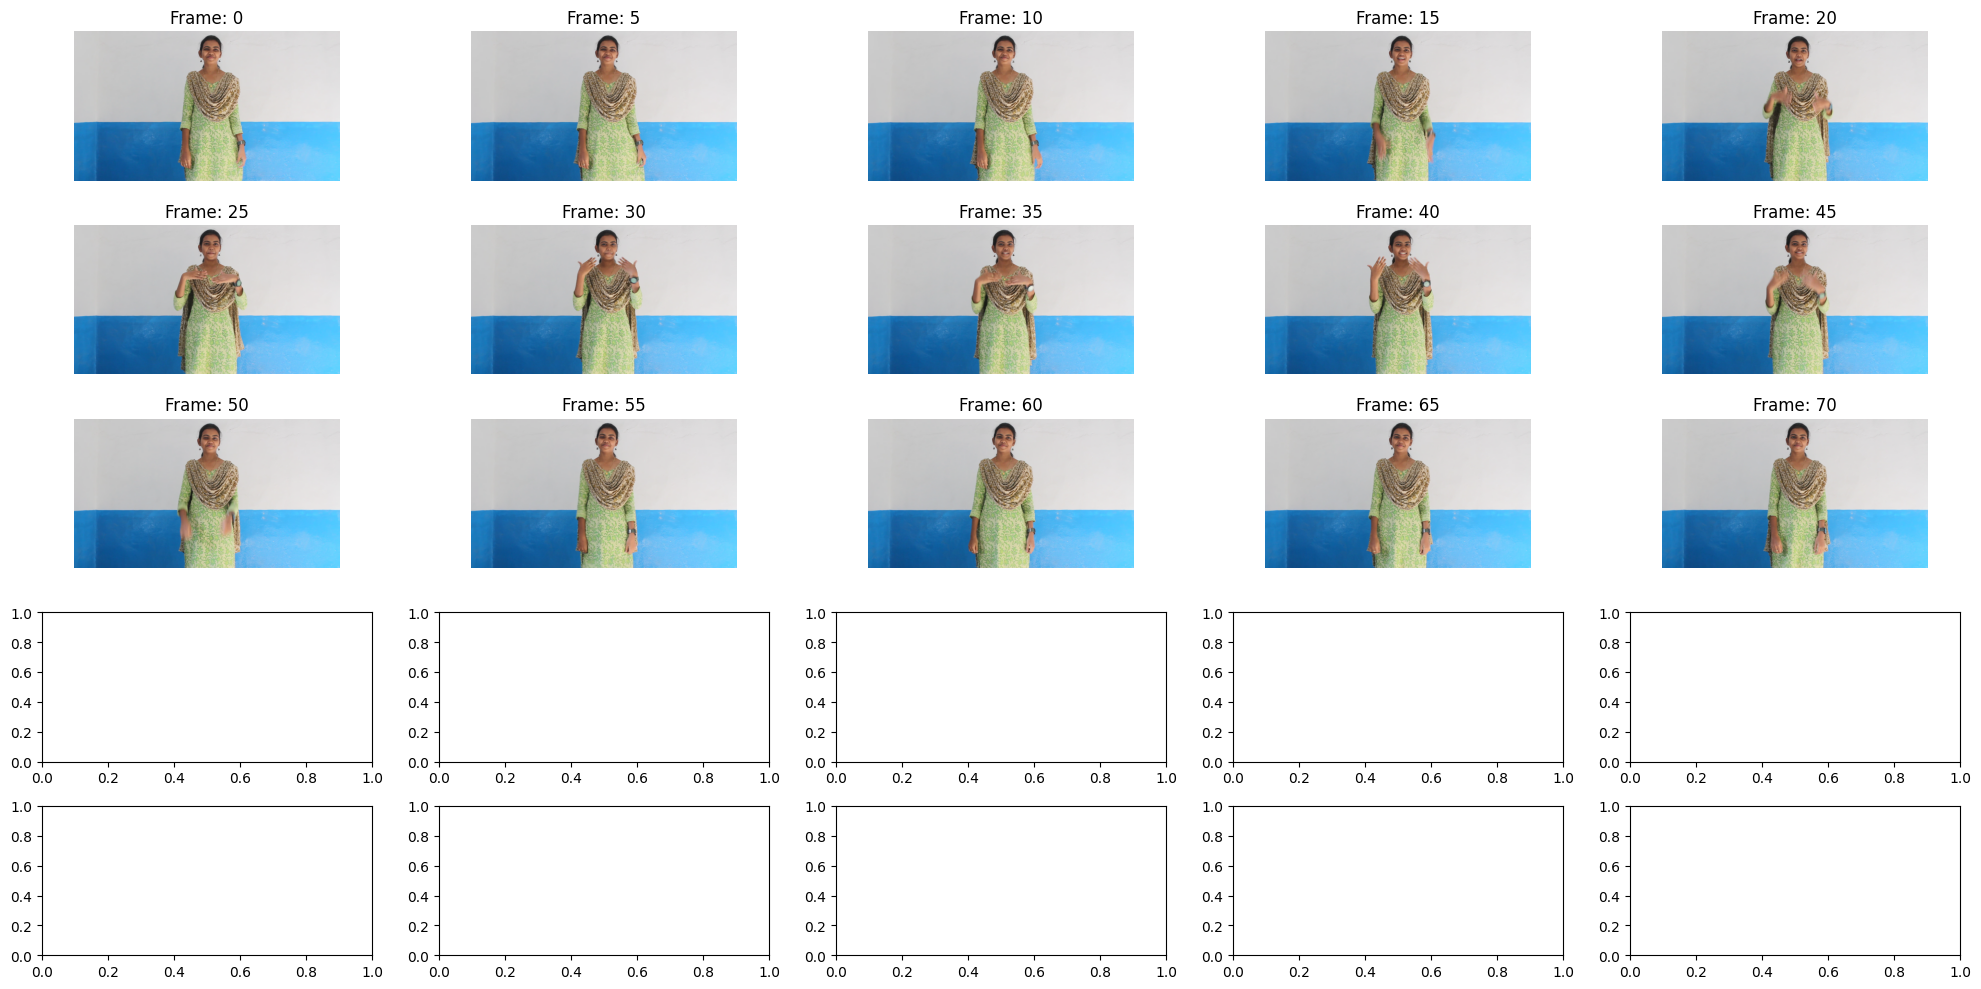

In [29]:
fig, axs = plt.subplots(5, 5, figsize=(20, 10))
axs = axs.flatten()

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    if ret == False:
        break
    if frame % 5 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()
cap.release()

## Vedio Augmentaion

1. Org  
2. Centre Crop
3. Flip
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred
8. Frame Skipping

### Centre Crop

In [30]:
def centered_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 600
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,700:1300] # Cropping
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Flip


In [31]:
def flip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1920
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,::-1] # Flipping
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Downsampling

In [32]:
def downsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    
    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 960
    height = 540
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrDown(img) # Downsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Upsampling


In [33]:
def upsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 3840
    height = 2160
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))



    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrUp(img) # Upsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Clipping


In [34]:
def clip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1920
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))



    counter = 0
    for frame in range(n_frames):
        ret, img = cap.read()
        if ret == False:
            break
        
        if counter >= 10 and counter < n_frames-20:    
            out.write(img)
        
        counter += 1

    out.release()
    cap.release()


In [22]:
for label in tqdm(glob('Dataset\*\*')): 
    label_name = " ".join(((label.split("\\")[-1]).split(" "))[1:]) # First seprated the label from dir then sep the label from its number and then join the label
    
    folder = "Clipped"

    os.makedirs(os.path.join(label,folder), exist_ok=True)
    videos = os.listdir(label)[1:]
    
    if "Extra" in videos:
        continue
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):
        input_video = os.path.join(label, video)
        cap = cv2.VideoCapture(input_video)
        n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,folder,f"{video[:-4]}.mp4")
        clip_video(input_video, save_path, cap, n_frames)

  0%|          | 0/10 [00:00<?, ?it/s]

11. rich:   0%|          | 0/9 [00:00<?, ?it/s]

12. poor:   0%|          | 0/9 [00:00<?, ?it/s]

13. thick:   0%|          | 0/9 [00:00<?, ?it/s]

14. thin:   0%|          | 0/5 [00:00<?, ?it/s]

...

18. curved:   0%|          | 0/9 [00:00<?, ?it/s]

21. tight:   0%|          | 0/9 [00:00<?, ?it/s]

84. small little:   0%|          | 0/23 [00:00<?, ?it/s]

85. slow:   0%|          | 0/22 [00:00<?, ?it/s]

86. fast:   0%|          | 0/22 [00:00<?, ?it/s]

## Genrating all the augmented content


In [36]:
for label in tqdm(glob('Dataset\*\*\Clipped')): 
    os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
    videos = os.listdir(label)[1:]
    
    
    
    for video in tqdm(videos,desc=label.split("\\")[-2]):        
        input_video = os.path.join(label, video)
        n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
        centered_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
        flip_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
        downsample_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
        upsample_video(input_video, save_path, cap, n_frames)
    

  0%|          | 0/15 [00:00<?, ?it/s]

11. rich:   0%|          | 0/8 [00:00<?, ?it/s]

12. poor:   0%|          | 0/8 [00:00<?, ?it/s]

13. thick:   0%|          | 0/8 [00:00<?, ?it/s]

14. thin:   0%|          | 0/4 [00:00<?, ?it/s]

...

7. Deaf:   0%|          | 0/8 [00:00<?, ?it/s]

8. Blind:   0%|          | 0/8 [00:00<?, ?it/s]

84. small little:   0%|          | 0/21 [00:00<?, ?it/s]

85. slow:   0%|          | 0/21 [00:00<?, ?it/s]

86. fast:   0%|          | 0/21 [00:00<?, ?it/s]

## Extracting mediapipe points from augmented vedios

In [1]:
# Setting up for mediapipe extraction of augmented videos
import mediapipe as mp
import utils

mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 
mp_utils = utils.MediapipeUtils(mp_holistic, mp_drawing)

In [ ]:
DATA_PATH = "MP_data\\"

mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)

video = "F:\Coding\Python\Signify\Dataset\Adjectives\\4. sad\Augmentation\MVI_9720_centered.mp4"

cap = cv2.VideoCapture(video)
all_keypoints = []
keypoints = np.array(None)

while cap.isOpened():           
    #Read feed
    ret, frame = cap.read()
    if not ret:
        break
    
    #Make detections
    image, results = mp_utils.mediapipe_detection(frame, holistic)
        
    #Collecting 3D landmarks for a single frame
    keypoints = mp_utils.extract_keypoints(results)
    all_keypoints.append(keypoints)        
    
all_keypoints = np.vstack(all_keypoints)

#Saving Landmarks
path = video.split("/")

#Getting Current action of the video
action = " ".join((video.split("\\")[-3]).split(" ")[1:]) 

#Get the sequence number
sequence = video.split("\\")[-1][:-4]

npy_path = os.path.join(DATA_PATH, action, sequence)

print(npy_path)

np.save(npy_path, all_keypoints)

cap.release()

MP_data\sad\MVI_9720_centered


In [3]:
DATA_PATH = "MP_data\\"
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(min_detection_confidence=0.7, min_tracking_confidence=0.7)



for label in tqdm(glob('Dataset\*\*\Clipped')): 
    
    vedios = os.listdir(os.path.join(label,"Augmentation"))
       
    for video in tqdm(vedios,desc=label.split("\\")[-2]):             
        
        try:
            video = os.path.join(label,"Augmentation",video)
            
            cap = cv2.VideoCapture(video)
            all_keypoints = []
            keypoints = np.array(None)
                
            while cap.isOpened():           
                # Read feed
                ret, frame = cap.read()
                if not ret:
                    break
                
                # Make detections
                image, results = mp_utils.mediapipe_detection(frame, holistic)
                    
                #Collecting 3D landmarks for a single frame
                keypoints = mp_utils.extract_keypoints(results)
                all_keypoints.append(keypoints)        
                
            all_keypoints = np.vstack(all_keypoints)
            
            # Saving Landmarks
            path = video.split("/")
            
            # Getting Current action of the video
            action = " ".join((video.split("\\")[-4]).split(" ")[1:]) 
            
            #Get the sequence number
            sequence = video.split("\\")[-1][:-4]
            
            npy_path = os.path.join(DATA_PATH, action, sequence)
            
            # print(npy_path)
            
            np.save(npy_path, all_keypoints)
            
            cap.release()
        except:
            pass
    
    print(all_keypoints.shape)

  0%|          | 0/16 [00:00<?, ?it/s]

1. loud:   0%|          | 0/84 [00:00<?, ?it/s]

(34, 258)


11. rich:   0%|          | 0/32 [00:00<?, ?it/s]

(32, 258)


...

(25, 258)


85. slow:   0%|          | 0/84 [00:00<?, ?it/s]

(35, 258)


86. fast:   0%|          | 0/84 [00:00<?, ?it/s]

(32, 258)
